# Definición del proyecto

## PRE EVALUACION CREDITICIA AUTOMATICA
contexto: el banco Wiesse ha registrado problemas en su cartera de creditos otorgados. Entoces deciden que quieren diseñar nuevas estrategias de control de entrega de prestamos con un sistema de preevaluacion soportando en Machine learning.

Un buen diseño de modelo Machine learning conllevara a mejorar la prediccion de la probabilidad de que alguien experimente dificultades financieras en los proximos dos años. Este modelo ayudara a los ejeutivos del banco para tener un control del riesgo de la entrega de prestamos.

Para lograr esta labor se ha revisado 3 años de historia crediticia de los clientes que se le realizaron los prestamos.

# Objetivo del proyecto

Desarrollar un modelo de Machine Learning capaz de predecir la probabilidad de que un cliente presente dificultades financieras en un horizonte de dos años, con el fin de apoyar el proceso de evaluación crediticia y reducir el riesgo en la entrega de préstamos.

# Importacion de librerias basicas

In [ ]:
#Import basicos
import pandas as pd #Manipulacion de datos
import numpy as np #Procesamiento de datos
import matplotlib #Visualizacion de datos
matplotlib.use('Agg')

import matplotlib.pyplot as plt #Visualizacion de datos
import seaborn as sns #Visualizacion de datos

sns.set(style='darkgrid') #Comando para el estilo de los gráficos
%matplotlib inline

# Carga inicial de datos

In [ ]:
fuga = pd.read_csv('/content/2_DS_creditos.csv',sep=",")

# Diccionario de datos

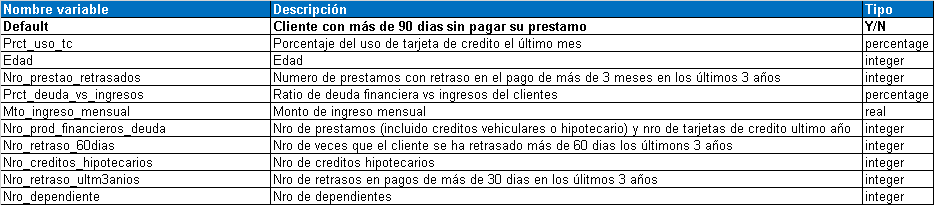

# Analisis de datos

## Insights

1. Se observa que la variable objetivo (Default) se encuentra desbalanceada, donde la mayoría de los clientes no presentan incumplimiento, mientras que un porcentaje menor sí lo hace. Esto puede afectar el desempeño de los modelos si no se aplican técnicas de balanceo.

2. Los clientes con mayor número de retrasos en pagos (Nro_retraso_60dias y Nro_retraso_ultm3anios) presentan una mayor probabilidad de incumplimiento, lo que indica que el historial de pagos es una variable clave.

3. Se identifica que un mayor porcentaje de deuda respecto a los ingresos (Prct_deuda_vs_ingresos) está asociado con un mayor riesgo de default, lo que sugiere que clientes con alta carga financiera son más propensos a incumplir.

4. Los clientes con menores ingresos mensuales tienden a presentar mayor riesgo de incumplimiento, lo cual puede influir en su capacidad de pago.

5. La cantidad de productos financieros y créditos también influye en el comportamiento del cliente, ya que un mayor número puede estar relacionado con un mayor nivel de endeudamiento y riesgo.

6. Se observa la presencia de valores atípicos en variables como ingresos y deuda, lo que justifica la aplicación de técnicas de tratamiento como estandarización o recorte de valores extremos.

## Analisis exploratorio de datos (EDA)

In [ ]:
fuga.head()

,ID,Default,Prct_uso_tc,Edad,Nro_prestao_retrasados,Prct_deuda_vs_ingresos,Mto_ingreso_mensual,Nro_prod_financieros_deuda,Nro_retraso_60dias,Nro_creditos_hipotecarios,Nro_retraso_ultm3anios,Nro_dependiente
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [ ]:
fuga.shape

(150000, 12)

**Hallazgo:**

El dataset cuenta con  un total de 12 columnas y 150.000 registros.

In [ ]:
fuga.columns

Index(['ID', 'Default', 'Prct_uso_tc', 'Edad', 'Nro_prestao_retrasados',
       'Prct_deuda_vs_ingresos', 'Mto_ingreso_mensual',
       'Nro_prod_financieros_deuda', 'Nro_retraso_60dias',
       'Nro_creditos_hipotecarios', 'Nro_retraso_ultm3anios',
       'Nro_dependiente'],
      dtype='object')

In [ ]:
#visualizar los primero registros
fuga.head(6)

,ID,Default,Prct_uso_tc,Edad,Nro_prestao_retrasados,Prct_deuda_vs_ingresos,Mto_ingreso_mensual,Nro_prod_financieros_deuda,Nro_retraso_60dias,Nro_creditos_hipotecarios,Nro_retraso_ultm3anios,Nro_dependiente
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
5,6,0,0.213179,74,0,0.375607,3500.0,3,0,1,0,1.0


In [ ]:
#visualizar los ultimos registros
fuga.tail()

,ID,Default,Prct_uso_tc,Edad,Nro_prestao_retrasados,Prct_deuda_vs_ingresos,Mto_ingreso_mensual,Nro_prod_financieros_deuda,Nro_retraso_60dias,Nro_creditos_hipotecarios,Nro_retraso_ultm3anios,Nro_dependiente
149995,149996,0,0.040674,74,0,0.225131,2100.0,4,0,1,0,0.0
149996,149997,0,0.299745,44,0,0.716562,5584.0,4,0,1,0,2.0
149997,149998,0,0.246044,58,0,3870.000000,NaN,18,0,1,0,0.0
149998,149999,0,0.000000,30,0,0.000000,5716.0,4,0,0,0,0.0
149999,150000,0,0.850283,64,0,0.249908,8158.0,8,0,2,0,0.0


In [ ]:
fuga.isnull().sum()

,0
ID,0
Default,0
Prct_uso_tc,0
Edad,0
Nro_prestao_retrasados,0
Prct_deuda_vs_ingresos,0
Mto_ingreso_mensual,29731
Nro_prod_financieros_deuda,0
Nro_retraso_60dias,0
Nro_creditos_hipotecarios,0


In [ ]:
fuga.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   ID                          150000 non-null  int64  
 1   Default                     150000 non-null  int64  
 2   Prct_uso_tc                 150000 non-null  float64
 3   Edad                        150000 non-null  int64  
 4   Nro_prestao_retrasados      150000 non-null  int64  
 5   Prct_deuda_vs_ingresos      150000 non-null  float64
 6   Mto_ingreso_mensual         120269 non-null  float64
 7   Nro_prod_financieros_deuda  150000 non-null  int64  
 8   Nro_retraso_60dias          150000 non-null  int64  
 9   Nro_creditos_hipotecarios   150000 non-null  int64  
 10  Nro_retraso_ultm3anios      150000 non-null  int64  
 11  Nro_dependiente             146076 non-null  float64
dtypes: float64(4), int64(8)
memory usage: 13.7 MB


**Hallazgo:**

 De las 12 variables, 4 son numéricas (8 enteras y 4 continuas).

 De las 12 variables, 2 presentan valores nulos:

*   Mto_ingreso_mensual: 29.731 registros
*   Nro_dependiente: 3.924 registros



podemos analizar y ve que tenemos un dataset que todos sus registros son numericos, no contamos con datos (alfabeticos)

**Cantidad de clientes que llevan mas 3 meses sin pagar**

Default
0    139974
1     10026
Name: count, dtype: int64


<Axes: xlabel='Default'>

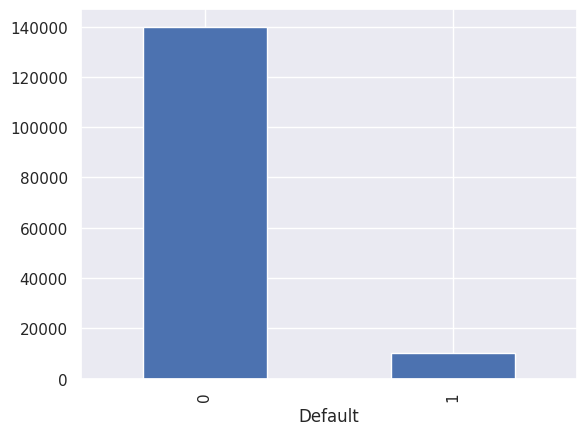

In [ ]:
# Calcular la cantidad de Clientes con más de 90 dias sin pagar su prestamo y los que si pagan su prestamo (defaul)
default_count = fuga["Default"].value_counts()
print(default_count)
# Visualizar la cantidad de clientes con más de 90 dias sin pagar su prestamo y los que si pagan su prestamo (defaul)
fuga["Default"].value_counts().plot(kind="bar")

In [ ]:
#Calcular la proporción de la variable Target
round(10026/150000,3)

0.067


Hallazgo:

Se observa que el 6.7%  de los clientes presenran un incumplimiento en el pado de su credito(default),mientras el 93.3% cumplen con sus obligaciones finacieras.Esto evidencia undesbalance en la variable objetivo. lo cual justifica la aplicacion de tecnica de balanceo de datos.

## Valores atipicos, analisis de mediana,promedio y desvacion estandar

In [ ]:
fuga.describe()

,ID,Default,Prct_uso_tc,Edad,Nro_prestao_retrasados,Prct_deuda_vs_ingresos,Mto_ingreso_mensual,Nro_prod_financieros_deuda,Nro_retraso_60dias,Nro_creditos_hipotecarios,Nro_retraso_ultm3anios,Nro_dependiente
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


Se procede a graficar las siguientes variabes con el fin de identificar visualmente la presencia de valores atipicos.

1. Mto_ingreso_mensual

2. Nro_prestao_retrasados

3. Nro_retraso_60dias

6. Nro_retraso_ultm3anios

A partir del analisis grafico, se observa que algunas variables presentan valores extremadamente altos, lo cual puede afectar el comportamiento del modelo
1. Prct_uso_tc

1. Prct_deuda_vs_ingresos

Presentan un alta desviasion estandar lo que inidica una gran dispersion en los datos y posible valores atipicos.


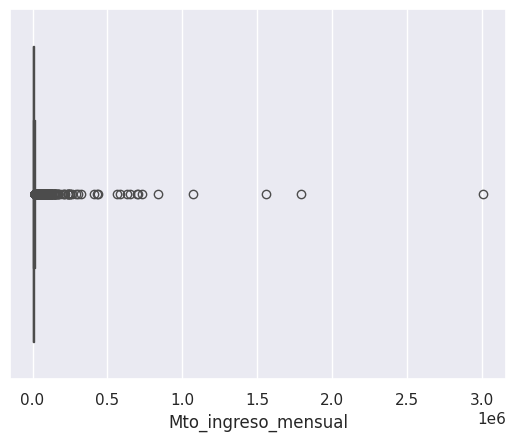

In [ ]:
sns.boxplot(x=fuga["Mto_ingreso_mensual"])
plt.show()

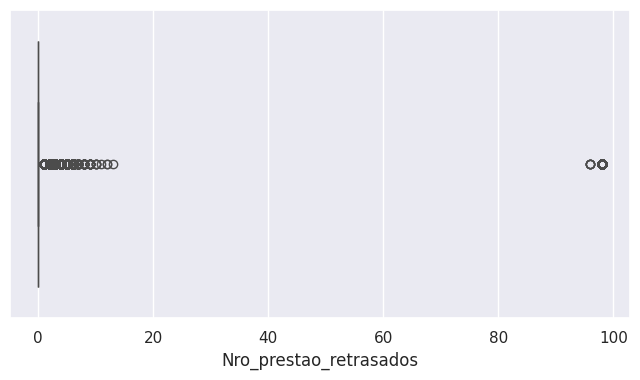

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(data=fuga, x = "Nro_prestao_retrasados")
plt.show()

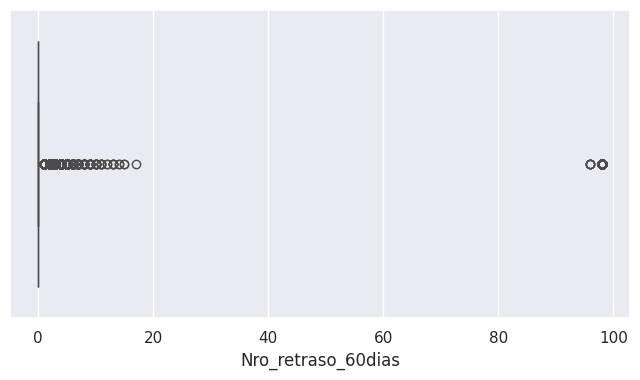

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(data=fuga, x = "Nro_retraso_60dias")
plt.show()

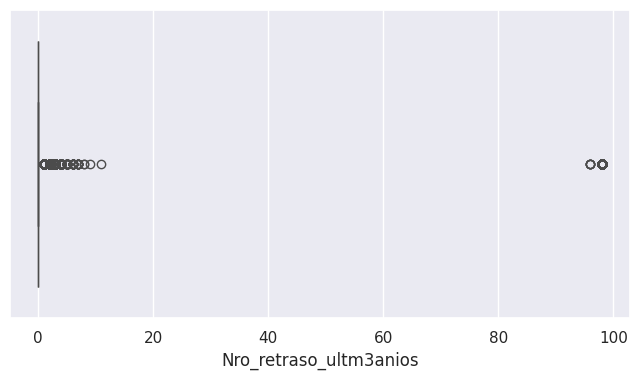

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(data=fuga, x = "Nro_retraso_ultm3anios")
plt.show()

In [ ]:
#cambio 99 a 1 hay estamos observando
fuga['Prct_uso_tc'].quantile(np.arange(0,1.01,0.1))

,Prct_uso_tc
0.0,0.000000
0.1,0.002969
0.2,0.019222
0.3,0.043461
0.4,0.083181
0.5,0.154181
0.6,0.271493
0.7,0.445136
0.8,0.698857
0.9,0.981278


In [ ]:
#cmabio desde 0.8 aproximadamente
fuga['Prct_deuda_vs_ingresos'].quantile(np.arange(0,1.01,0.1))

,Prct_deuda_vs_ingresos
0.0,0.000000
0.1,0.030874
0.2,0.133773
0.3,0.213697
0.4,0.287460
0.5,0.366508
0.6,0.467506
0.7,0.649189
0.8,4.000000
0.9,1267.000000


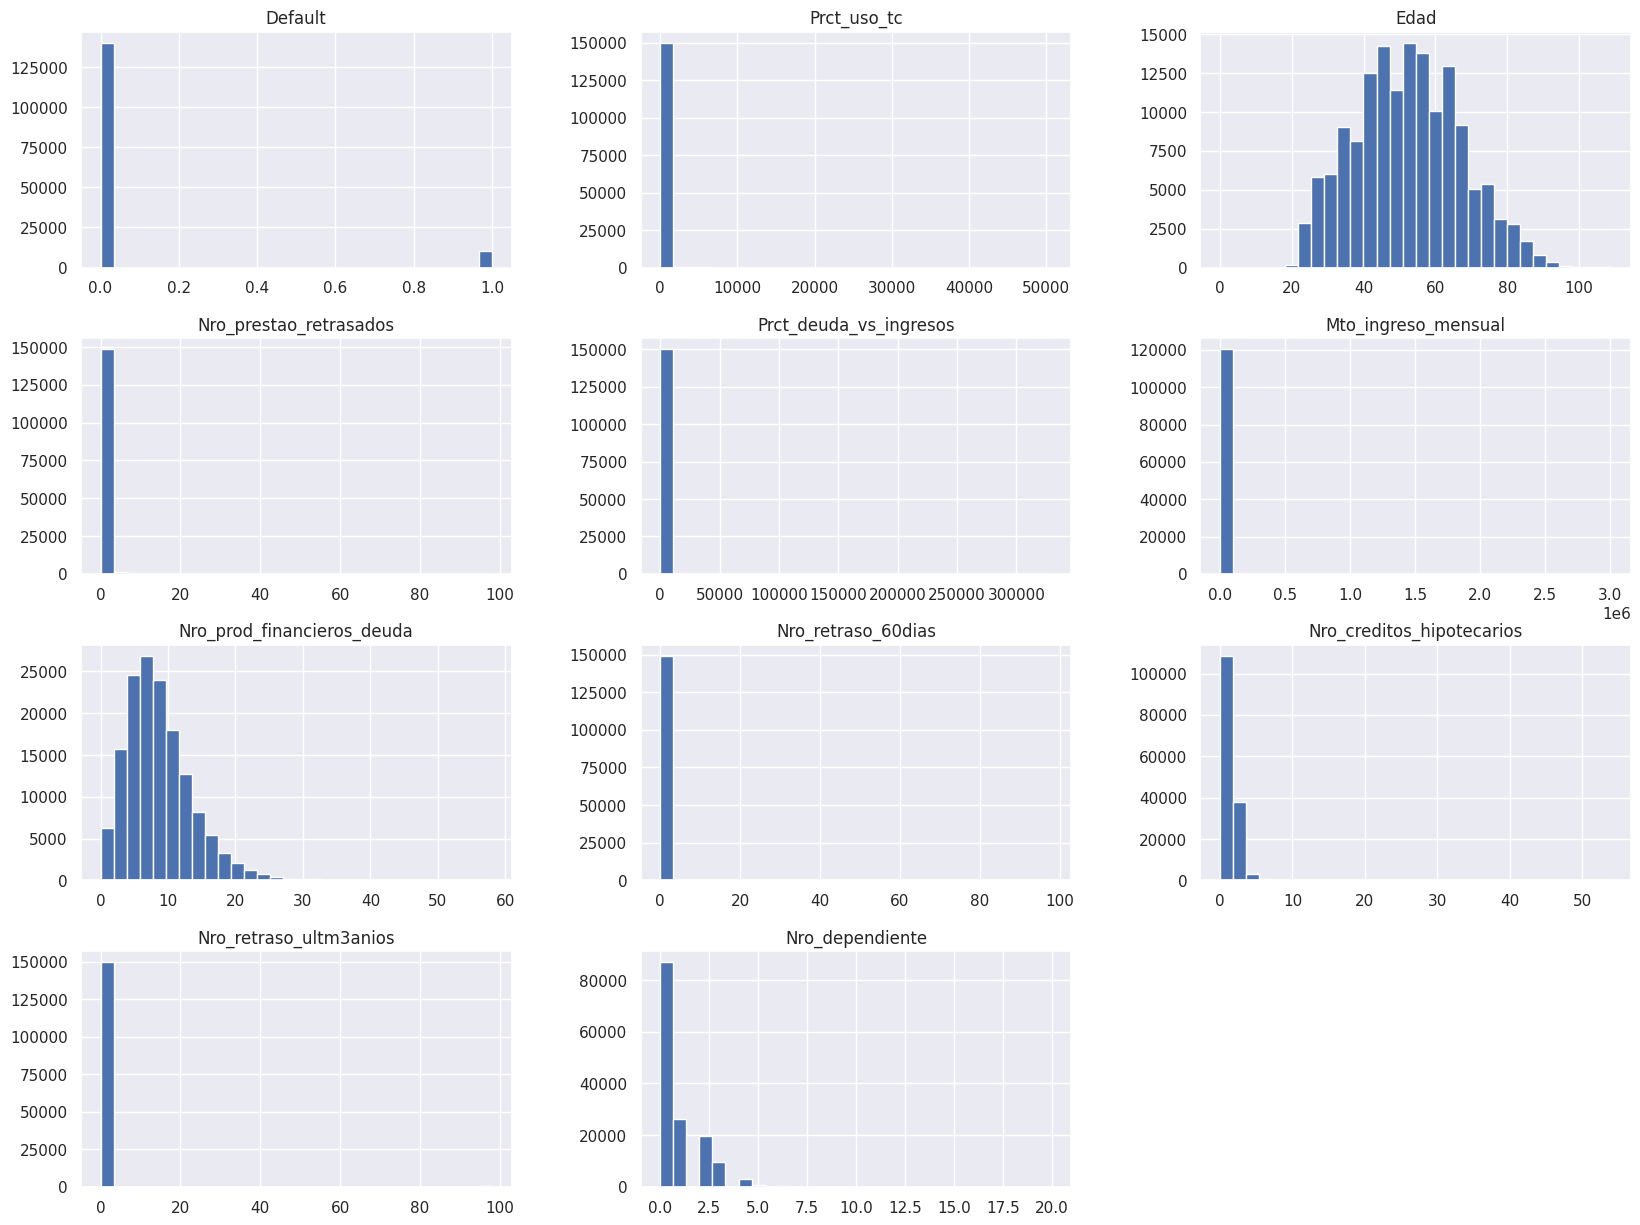

In [ ]:
columns_to_include = ['Default', 'Prct_uso_tc', 'Edad', 'Nro_prestao_retrasados', 'Prct_deuda_vs_ingresos', 'Mto_ingreso_mensual', 'Nro_prod_financieros_deuda', 'Nro_retraso_60dias', 'Nro_creditos_hipotecarios', 'Nro_retraso_ultm3anios', 'Nro_dependiente']
fuga[columns_to_include].hist(bins = 30, figsize=(20,15))
plt.show()

Se realizaron gráficos tipo boxplot con el fin de identificar la presencia de valores atípicos dentro del conjunto de datos. Adicionalmente, se elaboró un gráfico general donde se visualizan todas las variables.

A partir del análisis, se observa que la variable Edad presenta un promedio cercano a los 52 años. Aunque contiene algunos valores atípicos, estos no son tan extremos en comparación con otras variables.

Por otro lado, variables como ingresos, nivel de endeudamiento y número de retrasos presentan valores más extremos, lo que puede estar asociado a clientes con altos ingresos, elevados niveles de deuda o un historial significativo de incumplimientos en sus pagos.

Estos valores atípicos pueden influir en el comportamiento del modelo, por lo que es necesario analizarlos y tratarlos adecuadamente en las siguientes etapas del proyecto.

### Correlacion de los datos

<Axes: >

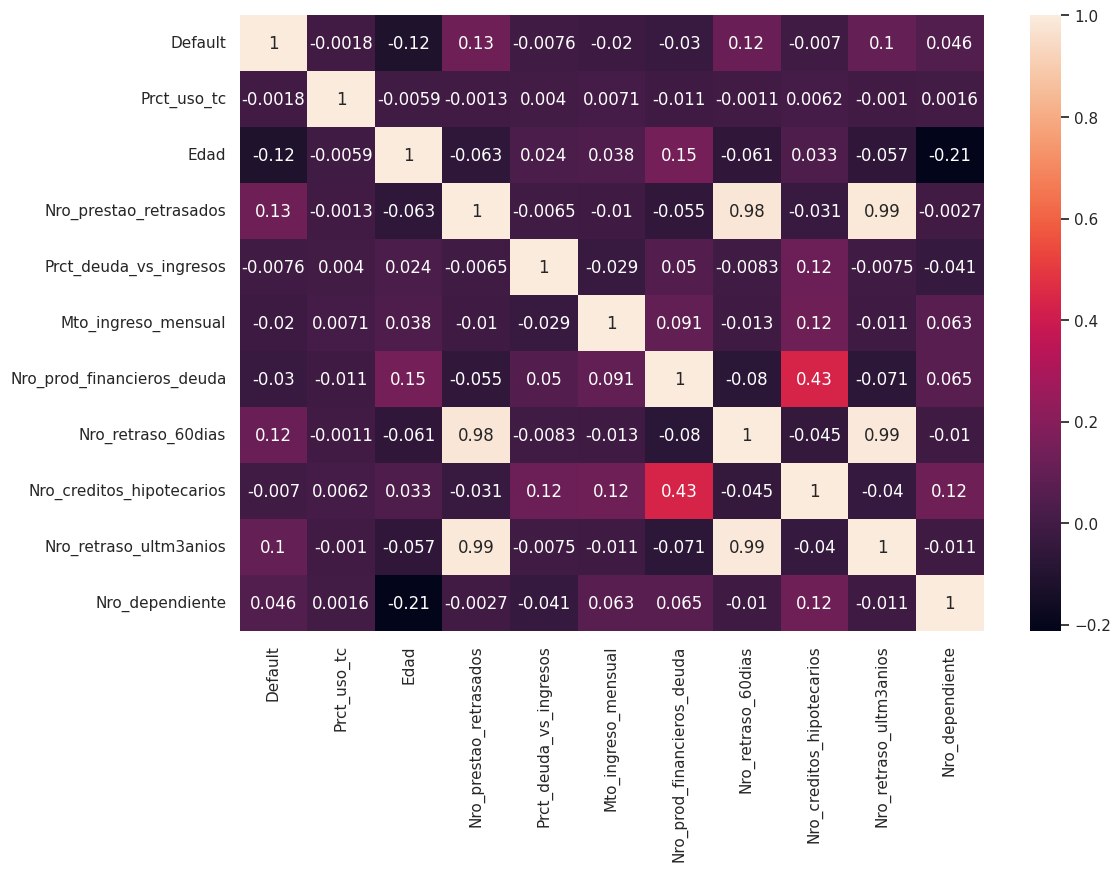

In [ ]:

corr = fuga[['Default', 'Prct_uso_tc', 'Edad', 'Nro_prestao_retrasados', 'Prct_deuda_vs_ingresos', 'Mto_ingreso_mensual', 'Nro_prod_financieros_deuda', 'Nro_retraso_60dias', 'Nro_creditos_hipotecarios', 'Nro_retraso_ultm3anios', 'Nro_dependiente']].corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True)

Se observa que las variables relacionadas con el historial de retrasos en pagos presentan una alta correlación entre sí, lo cual es esperado debido a que todas describen comportamientos similares del cliente frente a sus obligaciones financieras.
Asimismo, se identifican correlaciones positivas entre estas variables y la variable objetivo Default, lo que indica que los clientes con mayor número de retrasos presentan una mayor probabilidad de incumplimiento en sus pagos.

In [ ]:
corr_medv = corr['Default'].reindex(corr['Default'].abs().sort_values(ascending=False).index)
print(corr_medv)

Default                       1.000000
Nro_prestao_retrasados        0.125587
Nro_retraso_60dias            0.117175
Edad                         -0.115386
Nro_retraso_ultm3anios        0.102261
Nro_dependiente               0.046048
Nro_prod_financieros_deuda   -0.029669
Mto_ingreso_mensual          -0.019746
Prct_deuda_vs_ingresos       -0.007602
Nro_creditos_hipotecarios    -0.007038
Prct_uso_tc                  -0.001802
Name: Default, dtype: float64



Se analizó la correlación de las variables con la variable objetivo Default, con el fin de identificar los factores más relacionados con el incumplimiento de pago.

Los resultados evidencian que las variables con mayor correlación con el Default están asociadas al historial de retrasos en pagos, tales como Nro_prestao_retrasados, Nro_retraso_60dias y Nro_retraso_ultm3anios.
Esto indica que los clientes que han presentado retrasos en sus pagos tienen una mayor probabilidad de incurrir en incumplimiento.

Por otro lado, la variable Edad presenta una correlación negativa, lo que sugiere que a mayor edad, menor es la probabilidad de default.

En general, las correlaciones observadas son bajas, lo cual es esperado en este tipo de problemas, ya que el comportamiento financiero de los clientes depende de múltiples factores.


#Tratamiento de valores atipicos

Con base en el análisis previo de la distribución de los datos, se identificó que a partir de ciertos valores extremos las variables presentan cambios significativos en su comportamiento.

Por esta razón, se decidió aplicar un cuantíl del 0.98 (percentil 98) como umbral superior, ya que permite limitar los valores atípicos sin afectar la mayoría de los datos.

Este valor fue seleccionado debido a que, aproximadamente a partir de ese punto, se evidencian valores extremos que pueden distorsionar el análisis y el rendimiento de los modelos.

+ Prct_uso_tc
+ Nro_prestao_retrasados
+ Prct_deuda_vs_ingresos
+ Mto_ingreso_mensual
+ Nro_prod_financieros_deuda
+ Nro_retraso_60dias
+ Nro_creditos_hipotecarios
+ Nro_retraso_ultm3anios
+ Nro_dependiente

La variable Edad no fue tratada, ya que no presenta valores atípicos significativos.
Asimismo, la variable Default no se modifica, debido a que corresponde a la variable objetivo del modelo

In [ ]:
fuga.columns

Index(['ID', 'Default', 'Prct_uso_tc', 'Edad', 'Nro_prestao_retrasados',
       'Prct_deuda_vs_ingresos', 'Mto_ingreso_mensual',
       'Nro_prod_financieros_deuda', 'Nro_retraso_60dias',
       'Nro_creditos_hipotecarios', 'Nro_retraso_ultm3anios',
       'Nro_dependiente'],
      dtype='object')

In [ ]:
#APLICAR OUTLIER Este procedimiento permite conservar la información del dataset sin eliminar registros, mejorando la calidad de los datos para el modelado.
def outlier_capping(x):
    x = x.clip(upper=x.quantile(0.98)) #Percentil seleccionado

    return(x)

In [ ]:
#REEMPLAZAR LOS VALORES ATÍPICOS CON LA VARIABLE X DEFINIDA
df_creditos_tratamiento = fuga[['Prct_uso_tc', 'Nro_prestao_retrasados',
       'Prct_deuda_vs_ingresos', 'Mto_ingreso_mensual',
       'Nro_prod_financieros_deuda', 'Nro_retraso_60dias',
       'Nro_creditos_hipotecarios', 'Nro_retraso_ultm3anios',
       'Nro_dependiente']].apply(lambda x: outlier_capping(x))

In [ ]:
#VISUALIZAR LOS VALORES REEMPLAZADOS
df_creditos_tratamiento.head(3)

,Prct_uso_tc,Nro_prestao_retrasados,Prct_deuda_vs_ingresos,Mto_ingreso_mensual,Nro_prod_financieros_deuda,Nro_retraso_60dias,Nro_creditos_hipotecarios,Nro_retraso_ultm3anios,Nro_dependiente
0,0.766127,2,0.802982,9120.0,13,0,4,0,2.0
1,0.957151,0,0.121876,2600.0,4,0,0,0,1.0
2,0.658180,1,0.085113,3042.0,2,1,0,0,0.0


<Axes: >

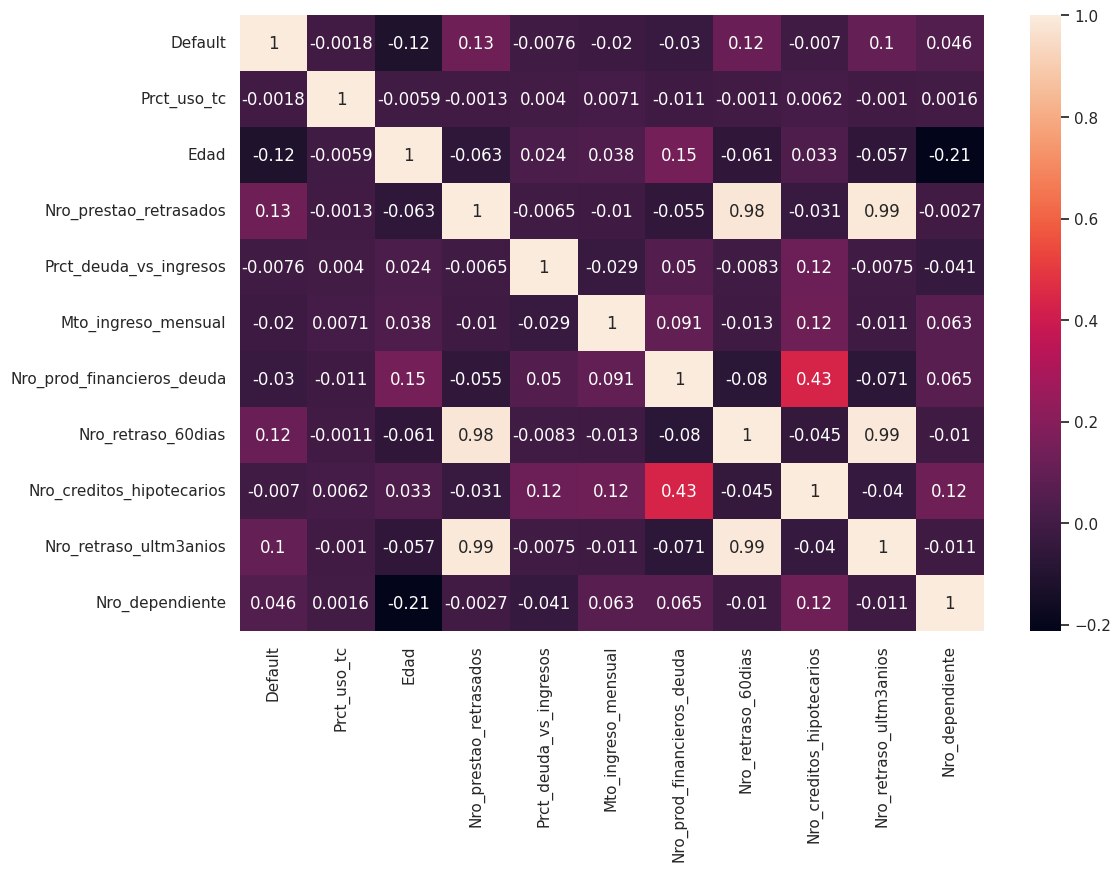

In [ ]:
#realizamos un nuevo cuadro de correlacion para analizar
corr = fuga[['Default', 'Prct_uso_tc', 'Edad', 'Nro_prestao_retrasados', 'Prct_deuda_vs_ingresos', 'Mto_ingreso_mensual', 'Nro_prod_financieros_deuda', 'Nro_retraso_60dias', 'Nro_creditos_hipotecarios', 'Nro_retraso_ultm3anios', 'Nro_dependiente']].corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True)

In [ ]:
corr_medv = corr['Default'].reindex(corr['Default'].abs().sort_values(ascending=False).index)
print(corr_medv)

Default                       1.000000
Nro_prestao_retrasados        0.125587
Nro_retraso_60dias            0.117175
Edad                         -0.115386
Nro_retraso_ultm3anios        0.102261
Nro_dependiente               0.046048
Nro_prod_financieros_deuda   -0.029669
Mto_ingreso_mensual          -0.019746
Prct_deuda_vs_ingresos       -0.007602
Nro_creditos_hipotecarios    -0.007038
Prct_uso_tc                  -0.001802
Name: Default, dtype: float64


Después de aplicar el tratamiento de valores atípicos mediante el uso de cuantiles, se realizó nuevamente el análisis de correlación con la variable objetivo Default.

Se observa que las relaciones entre las variables se mantienen similares a las obtenidas en el análisis inicial, especialmente en aquellas relacionadas con el historial de retrasos en pagos.

Esto indica que el tratamiento de valores atípicos no alteró significativamente la estructura de los datos ni las relaciones entre variables.

Por lo tanto, se puede concluir que los valores extremos no tenían un impacto considerable en la correlación, pero su tratamiento contribuye a mejorar la estabilidad del modelo.

# Tratamiento de valores nulos y eliminacion de columnas

Durante el análisis exploratorio se identificó la presencia de valores nulos en algunas variables del conjunto de datos, específicamente en Mto_ingreso_mensual y Nro_dependiente.

La presencia de valores nulos puede afectar el rendimiento de los modelos, por lo que es necesario aplicar técnicas de imputación para completar la información faltante.

In [ ]:
# Para el tratamiento de valores nulos, se utilizó la mediana como medida de reemplazo, ya que es menos sensible a valores atípicos en comparación con el promedio

fuga["Mto_ingreso_mensual"].fillna(fuga["Mto_ingreso_mensual"].median(), inplace=True)
fuga["Nro_dependiente"].fillna(fuga["Nro_dependiente"].median(), inplace=True)

/tmp/ipykernel_1051/582241977.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  fuga["Mto_ingreso_mensual"].fillna(fuga["Mto_ingreso_mensual"].median(), inplace=True)
/tmp/ipykernel_1051/582241977.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col

In [ ]:
#visualizamos que no exiten valores nulos en el dataset, asegurando la calidad de los datos para el modelado.
fuga.isnull().sum()

,0
ID,0
Default,0
Prct_uso_tc,0
Edad,0
Nro_prestao_retrasados,0
Prct_deuda_vs_ingresos,0
Mto_ingreso_mensual,0
Nro_prod_financieros_deuda,0
Nro_retraso_60dias,0
Nro_creditos_hipotecarios,0


In [ ]:
#data
fuga.head()

,ID,Default,Prct_uso_tc,Edad,Nro_prestao_retrasados,Prct_deuda_vs_ingresos,Mto_ingreso_mensual,Nro_prod_financieros_deuda,Nro_retraso_60dias,Nro_creditos_hipotecarios,Nro_retraso_ultm3anios,Nro_dependiente
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [ ]:
fuga.columns

Index(['ID', 'Default', 'Prct_uso_tc', 'Edad', 'Nro_prestao_retrasados',
       'Prct_deuda_vs_ingresos', 'Mto_ingreso_mensual',
       'Nro_prod_financieros_deuda', 'Nro_retraso_60dias',
       'Nro_creditos_hipotecarios', 'Nro_retraso_ultm3anios',
       'Nro_dependiente'],
      dtype='object')

In [ ]:
# analisamos y se va eliminar la columna ID del conjunto de datos, ya que corresponde a un identificador unico que no aporta informacion revalante para el modelo.

drop_elements = ['ID']

In [ ]:
# la eliminacion de esta variable permite evitar ruido en el modelo.
fuga_encoded = fuga.drop(drop_elements, axis = 1)

In [ ]:
#generamos nuestro data final
fuga_encoded.head(3)

,Default,Prct_uso_tc,Edad,Nro_prestao_retrasados,Prct_deuda_vs_ingresos,Mto_ingreso_mensual,Nro_prod_financieros_deuda,Nro_retraso_60dias,Nro_creditos_hipotecarios,Nro_retraso_ultm3anios,Nro_dependiente
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0


<Axes: >

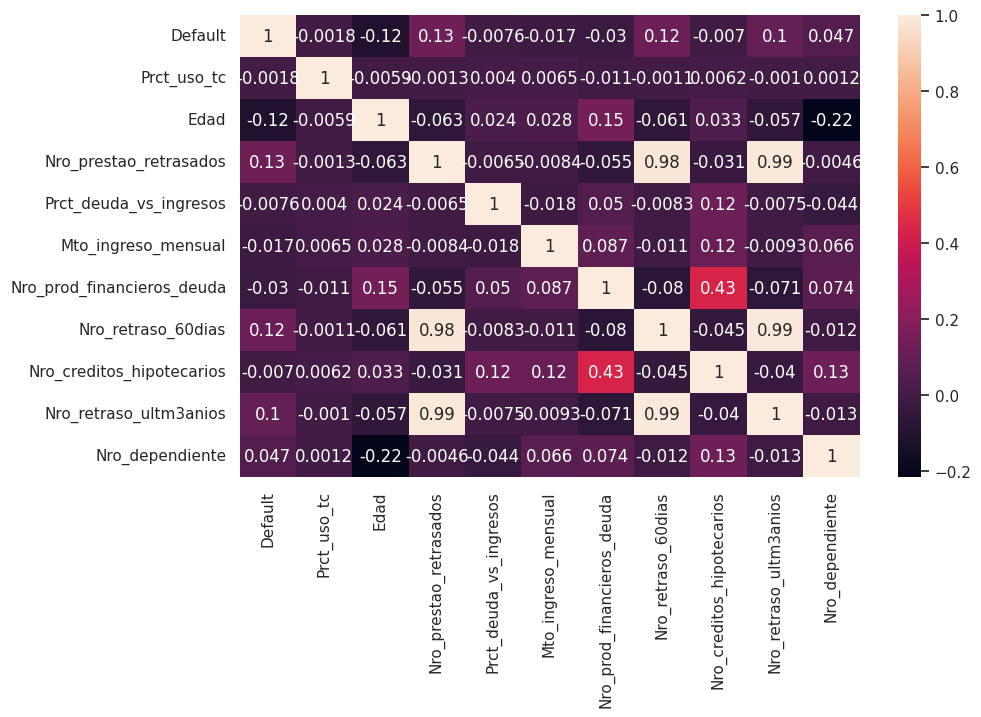

In [ ]:
#miramos la correlacion ya que no hay datos nulos porque se uso la media
corr = fuga_encoded.corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True)

In [ ]:
corr_medv = corr['Default'].reindex(corr['Default'].abs().sort_values(ascending=False).index)
print(corr_medv)

Default                       1.000000
Nro_prestao_retrasados        0.125587
Nro_retraso_60dias            0.117175
Edad                         -0.115386
Nro_retraso_ultm3anios        0.102261
Nro_dependiente               0.046869
Nro_prod_financieros_deuda   -0.029669
Mto_ingreso_mensual          -0.017151
Prct_deuda_vs_ingresos       -0.007602
Nro_creditos_hipotecarios    -0.007038
Prct_uso_tc                  -0.001802
Name: Default, dtype: float64


En el análisis inicial se identificó la presencia de valores nulos en dos variables del dataset. Posteriormente, tras aplicar el tratamiento de valores nulos mediante la imputación con la mediana, se puede evidenciar que el conjunto de datos ya no presenta valores faltantes.

Adicionalmente, la columna ID fue eliminada, ya que no aporta valor al proceso de modelamiento al ser únicamente un identificador.

Al realizar nuevamente el análisis de correlación, se observa que las relaciones entre las variables se mantienen similares a las obtenidas en los análisis anteriores.

Esto indica que el tratamiento de valores nulos no generó cambios significativos en la estructura de los datos, lo cual es consistente con el uso de la mediana como método de imputación

# Separacion de variables
Se realizó la separación de las variables del dataset en variables independientes (X) y variable objetivo (y).
La variable Default se define como la variable objetivo, ya que representa el incumplimiento de pago que se desea predecir.

In [ ]:
from sklearn.feature_selection import SelectKBest

X=fuga_encoded.drop(['Default'], axis=1)
y=fuga_encoded['Default']

best=SelectKBest(k=5) # Cambiado de k=3 a k=5 para seleccionar más características
X_new = best.fit_transform(X, y)
X_new.shape
selected = best.get_support(indices=True)
print(X.columns[selected])

Index(['Edad', 'Nro_prestao_retrasados', 'Nro_retraso_60dias',
       'Nro_retraso_ultm3anios', 'Nro_dependiente'],
      dtype='object')


Con el objetivo de mejorar el rendimiento del modelo, se realizó una selección de variables utilizando el método SelectKBest, el cual permite identificar las variables con mayor relación con la variable objetivo Default.
Como resultado, se seleccionaron las siguientes variables:
Edad
1. Nro_prestao_retrasados
2. Nro_retraso_60dias
3. Nro_retraso_ultm3anios
4. Nro_dependiente

Se observa que las variables seleccionadas están principalmente asociadas al comportamiento de pago del cliente, lo cual confirma su importancia en la predicción del riesgo crediticio.

# Balanceo de Datos

En el análisis previo se identificó un desbalance en la variable objetivo Default, donde aproximadamente el 6.7% de los clientes presentan incumplimiento, mientras que el 93.3% cumplen con sus pagos.

Este desbalance puede afectar el rendimiento de los modelos de Machine Learning, ya que tienden a favorecer la clase mayoritaria

### DIVISION DE DATOS

Con el fin de evaluar el desempeño de los modelos de Machine Learning, se realizó la división del conjunto de datos en entrenamiento y prueba.
Se utilizó el 70% de los datos para el entrenamiento del modelo (train) y el 30% para su evaluación (test), permitiendo validar su capacidad de generalización en datos no vistos.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, log_loss

In [ ]:
#separacion en train y test
X = fuga_encoded[['Edad', 'Nro_prestao_retrasados', 'Nro_retraso_60dias',
       'Nro_retraso_ultm3anios', 'Nro_dependiente']]
y = fuga_encoded[['Default']]

import sklearn.model_selection as model_selection
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, train_size=0.3,test_size=0.7, random_state=1206)

In [ ]:
df_train = pd.concat([X_train,y_train],axis=1)

In [ ]:
count_class_0, count_class_1 = df_train.Default.value_counts()

df_class_0 = df_train[df_train['Default'] == 0]
df_class_1 = df_train[df_train['Default'] == 1]

In [ ]:
count_class_0, len(df_class_0), count_class_1, len(df_class_1)

(41981, 41981, 3019, 3019)

In [ ]:
97954+7046

105000

In [ ]:
7046/105000

0.0671047619047619

## Undersampling

consiste en reducir la cantidad de registros de la clase mayoritaria hasta igualarla con la clase minoritaria, con el fin de equilibrar la distribución de la variable objetivo.
Este método permite disminuir el sesgo del modelo hacia la clase mayoritaria, aunque puede implicar la pérdida de información.

In [ ]:
df_class_0_under = df_class_0.sample(count_class_1,random_state=1206)

In [ ]:
df_train_under = pd.concat([df_class_0_under, df_class_1], axis=0)

Estrategia de Muestreo under-sampling:
Default
0    3019
1    3019
Name: count, dtype: int64


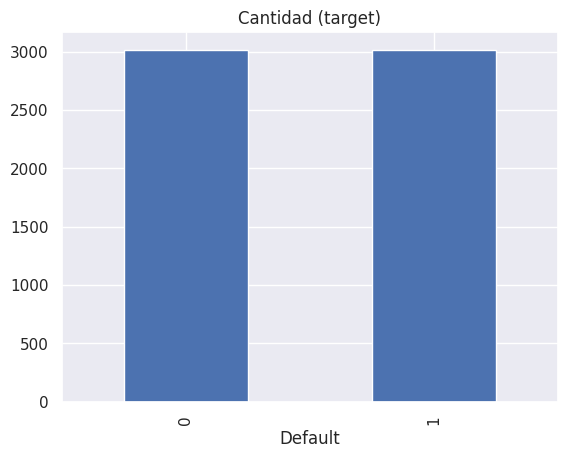

In [ ]:
#grafica donde se evidencia que estaban balanciadas
print('Estrategia de Muestreo under-sampling:')
print(df_train_under.Default.value_counts())

df_train_under.Default.value_counts().plot(kind='bar', title='Cantidad (target)');

## Oversampling
consiste en aumentar la cantidad de registros de la clase minoritaria hasta igualarla con la clase mayoritaria, con el fin de equilibrar la distribución de la variable objetivo.
Este método permite mejorar la capacidad del modelo para identificar la clase minoritaria, aunque puede generar sobreajuste al duplicar información.

In [ ]:
df_class_1_over = df_class_1.sample(count_class_0, replace=True)

In [ ]:
df_train_over = pd.concat([df_class_0, df_class_1_over], axis=0)


Estrategia de Muestreo over-sampling:
Default
0    41981
1    41981
Name: count, dtype: int64


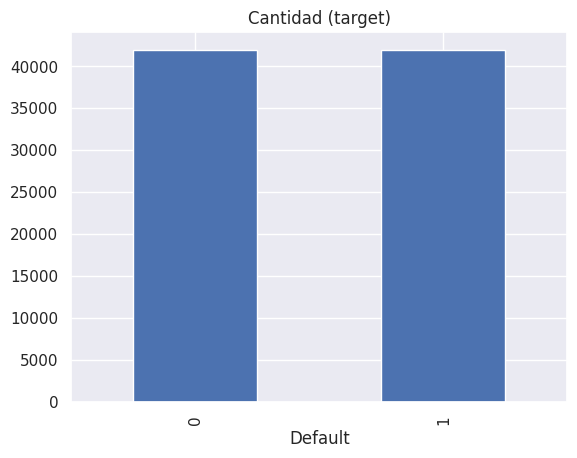

In [ ]:
print('Estrategia de Muestreo over-sampling:')
print(df_train_over.Default.value_counts())

df_train_over.Default.value_counts().plot(kind='bar', title='Cantidad (target)');

## Resumen de las fuentes de Train

A continuación, se presenta un resumen de la distribución de la variable objetivo en los diferentes conjuntos de entrenamiento utilizados:

In [ ]:
#Train Original
df_train.Default.value_counts()

,count
Default,
0,41981
1,3019


In [ ]:
#Train Undersampling
df_train_under.Default.value_counts()

,count
Default,
0,3019
1,3019


In [ ]:
#Train Oversampling
df_train_over.Default.value_counts()

,count
Default,
0,41981
1,41981


## Evaluacion de balanceo

Con el objetivo de analizar el impacto de las técnicas de balanceo en el desempeño del modelo, se realizó una evaluación utilizando diferentes conjuntos de entrenamiento: datos originales, undersampling y oversampling.

Aca se declaran los modelos

In [ ]:
#declaramos librerias
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, log_loss

#Declarando el modelo
model = DecisionTreeClassifier()
#Entrenando el modelo
model.fit(X_train, y_train)
#Prediciendo el modelo
y_pred_1 = model.predict(X_test)

In [ ]:
#Declarar el modelo Undersampling
model = DecisionTreeClassifier()
#Defino mi base de train
X_train_u= df_train_under[['Edad', 'Nro_prestao_retrasados', 'Nro_retraso_60dias',
       'Nro_retraso_ultm3anios', 'Nro_dependiente']]
y_train_u = df_train_under[['Default']]
#Entrenando el modelo
model.fit(X_train_u, y_train_u)
#Prediciendo el modelo
y_pred_2 = model.predict(X_test)

In [ ]:
#Declarar el modelo Oversampling
model = DecisionTreeClassifier()
#Defino mi base de train
X_train_o= df_train_over[['Edad', 'Nro_prestao_retrasados', 'Nro_retraso_60dias',
       'Nro_retraso_ultm3anios', 'Nro_dependiente']]
y_train_o = df_train_over[['Default']]
#Entrenando el modelo
model.fit(X_train_o, y_train_o)
#Prediciendo el modelo
y_pred_3 = model.predict(X_test)

### Matriz de confusión

Con el fin de evaluar el desempeño del modelo de clasificación, se utiliza la matriz de confusión, la cual permite analizar las predicciones realizadas comparándolas con los valores reales.
Esta herramienta permite identificar el número de aciertos y errores, facilitando la evaluación del modelo especialmente en problemas con clases desbalanceadas.

In [ ]:
#Original
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred_1)

array([[96451,  1542],
       [ 5766,  1241]])

In [ ]:
#Undersampling
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred_2)

array([[82792, 15201],
       [ 3091,  3916]])

In [ ]:
#Oversampling
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred_3)

array([[84798, 13195],
       [ 4233,  2774]])

### Métricas
Con el fin de evaluar el desempeño de los modelos de clasificación, se emplean métricas como accuracy, precision, recall y F1-score.
Estas métricas permiten medir la calidad de las predicciones, especialmente en problemas con datos desbalanceados, donde es fundamental evaluar la capacidad del modelo para identificar correctamente la clase minoritaria

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
#Original Categoría: Precision 45%, recall 18% y F1 score 25%
print(classification_report(y_test,y_pred_1))

              precision    recall  f1-score   support

           0       0.94      0.98      0.96     97993
           1       0.45      0.18      0.25      7007

    accuracy                           0.93    105000
   macro avg       0.69      0.58      0.61    105000
weighted avg       0.91      0.93      0.92    105000



In [ ]:
#Undersampling Categoría: Precision 20%, recall 56% y F1 score 30%
print(classification_report(y_test,y_pred_2))

              precision    recall  f1-score   support

           0       0.96      0.84      0.90     97993
           1       0.20      0.56      0.30      7007

    accuracy                           0.83    105000
   macro avg       0.58      0.70      0.60    105000
weighted avg       0.91      0.83      0.86    105000



In [ ]:
#Oversampling Categoría: Precision 17%, recall 40% y F1 score 24%
print(classification_report(y_test,y_pred_3))

              precision    recall  f1-score   support

           0       0.95      0.87      0.91     97993
           1       0.17      0.40      0.24      7007

    accuracy                           0.83    105000
   macro avg       0.56      0.63      0.57    105000
weighted avg       0.90      0.83      0.86    105000



Para determinar la mejor técnica de balanceo, se compararon las métricas obtenidas en los tres escenarios: datos originales, undersampling y oversampling.

Se observa que el modelo con datos originales presenta un alto accuracy, pero un bajo recall, lo que indica que no logra identificar adecuadamente la clase minoritaria.

Al aplicar oversampling, se evidencia una mejora en el recall; sin embargo, el modelo aún presenta limitaciones en el equilibrio de las métricas.

Por otro lado, el undersampling muestra un mejor desempeño, logrando un mayor recall y un mejor F1-score, lo que indica un equilibrio más adecuado entre precisión y capacidad de detección.

Por esta razón, se selecciona el undersampling como la mejor técnica de balanceo para este problema.

## Modelado
En esta etapa se construyen diferentes modelos de clasificación con el objetivo de predecir el incumplimiento de los clientes.

Para ello, se implementan algoritmos como XGBoost, Random Forest y Regresión Logística, los cuales serán evaluados posteriormente para determinar cuál presenta un mejor desempeño.

In [ ]:
#Instalar la librería
!pip install xgboost

### xgboost

In [ ]:
#Importar la librería
import xgboost as xgb 

#Declaro el modelo
model1 = xgb.XGBClassifier()
#Entrenando el modelo
model1.fit(X_train_u, y_train_u)
#Prediciendo el modelo
pred_1 = model1.predict(X_test)

In [ ]:
#XGBoost Tuneado (Cuando registros mis propios parámetros)

#Declaro el modelo
model2 = xgb.XGBClassifier(n_estimators = 20, max_depth = 8, learning_rate = 0.1, subsample = 0.5)
#Entrenando el modelo
model2.fit(X_train_u, y_train_u)
#Prediciendo el modelo
pred_2 = model2.predict(X_test)

### Random Forest

In [ ]:
#random forest
from sklearn.ensemble import RandomForestClassifier

#Declaro el modelo
model3 = RandomForestClassifier()
#Entrenando el modelo
model3.fit(X_train_u, y_train_u.values.ravel())
#Prediciendo el modelo
pred_3 = model3.predict(X_test)

In [ ]:
#random forest Tuneado o Modificado
from sklearn.ensemble import RandomForestClassifier

#Declaro el modelo
model4 = RandomForestClassifier(n_estimators = 20, max_depth = 8)
#Entrenando el modelo
model4.fit(X_train_u, y_train_u.values.ravel())
#Prediciendo el modelo
pred_4 = model4.predict(X_test)

### Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

#Declaro el modelo
model_5 = LogisticRegression()
#Entrenando el modelo
model_5.fit(X_train_u, y_train_u.values.ravel())
#Prediciendo el modelo
pred_5 = model_5.predict(X_test)

In [ ]:
#Logistic Regression tuneado o modificado
from sklearn.linear_model import LogisticRegression

#Declaro el modelo
model_6 = LogisticRegression(C=0.1, solver='liblinear', max_iter=1000)
#Entrenando el modelo
model_6.fit(X_train_u, y_train_u.values.ravel())
#Prediciendo el modelo
pred_6 = model_6.predict(X_test)

# Evaluacion

En esta etapa se evalúa el desempeño de los modelos de clasificación implementados, con el fin de comparar sus resultados y seleccionar el modelo más adecuado.

Para ello, se utilizan métricas como accuracy, precision, recall y F1-score, las cuales permiten analizar la calidad de las predicciones, especialmente en la detección de la clase minoritaria.

In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, pred_1)

array([[79612, 18381],
       [ 2292,  4715]])

In [ ]:
print(classification_report(y_test,pred_1))

              precision    recall  f1-score   support

           0       0.97      0.81      0.89     97993
           1       0.20      0.67      0.31      7007

    accuracy                           0.80    105000
   macro avg       0.59      0.74      0.60    105000
weighted avg       0.92      0.80      0.85    105000



In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, pred_2)

array([[80252, 17741],
       [ 2270,  4737]])

In [ ]:
print(classification_report(y_test,pred_2))

              precision    recall  f1-score   support

           0       0.97      0.82      0.89     97993
           1       0.21      0.68      0.32      7007

    accuracy                           0.81    105000
   macro avg       0.59      0.75      0.61    105000
weighted avg       0.92      0.81      0.85    105000



In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, pred_3)

array([[79488, 18505],
       [ 2540,  4467]])

In [ ]:
print(classification_report(y_test,pred_3))

              precision    recall  f1-score   support

           0       0.96      0.86      0.91     97993
           1       0.18      0.44      0.26      7007

    accuracy                           0.83    105000
   macro avg       0.57      0.65      0.58    105000
weighted avg       0.90      0.83      0.86    105000



In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, pred_4)

array([[79748, 18245],
       [ 2180,  4827]])

In [ ]:
print(classification_report(y_test,pred_4))

              precision    recall  f1-score   support

           0       0.97      0.81      0.89     97993
           1       0.21      0.69      0.32      7007

    accuracy                           0.81    105000
   macro avg       0.59      0.75      0.60    105000
weighted avg       0.92      0.81      0.85    105000



In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, pred_5)

array([[73787, 24206],
       [ 2396,  4611]])

In [ ]:
print(classification_report(y_test,pred_5))

              precision    recall  f1-score   support

           0       0.97      0.75      0.85     97993
           1       0.16      0.66      0.26      7007

    accuracy                           0.75    105000
   macro avg       0.56      0.71      0.55    105000
weighted avg       0.91      0.75      0.81    105000



In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, pred_6)

array([[75824, 22169],
       [ 2430,  4577]])

In [ ]:
print(classification_report(y_test,pred_6))

              precision    recall  f1-score   support

           0       0.97      0.77      0.86     97993
           1       0.17      0.65      0.27      7007

    accuracy                           0.77    105000
   macro avg       0.57      0.71      0.57    105000
weighted avg       0.92      0.77      0.82    105000



### A continuacion, se presenta un resumen comparativo de los modelos evaluados

In [ ]:
#vamos agrupar todos los resultados en una sola tabla
resultados = pd.DataFrame(columns=["Modelo","Accuracy","Precision","Recall","F1"])

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Crear tabla vacía
resultados = pd.DataFrame(columns=["Modelo","Accuracy","Precision","Recall","F1"])

# XGBoost
resultados.loc[len(resultados)] = [
"XGBoost",
accuracy_score(y_test, pred_1),
precision_score(y_test, pred_1),
recall_score(y_test, pred_1),
f1_score(y_test, pred_1)
]

# XGBoost Tuneado
resultados.loc[len(resultados)] = [
"XGBoost Tuneado",
accuracy_score(y_test, pred_2),
precision_score(y_test, pred_2),
recall_score(y_test, pred_2),
f1_score(y_test, pred_2)
]

# Random Forest
resultados.loc[len(resultados)] = [
"Random Forest",
accuracy_score(y_test, pred_3),
precision_score(y_test, pred_3),
recall_score(y_test, pred_3),
f1_score(y_test, pred_3)
]

# Random Forest Tuneado
resultados.loc[len(resultados)] = [
"Random Forest Tuneado",
accuracy_score(y_test, pred_4),
precision_score(y_test, pred_4),
recall_score(y_test, pred_4),
f1_score(y_test, pred_4)
]

# Logistic Regression
resultados.loc[len(resultados)] = [
"Logistic Regression",
accuracy_score(y_test, pred_5),
precision_score(y_test, pred_5),
recall_score(y_test, pred_5),
f1_score(y_test, pred_5)
]

# Logistic Regression Tuneado
resultados.loc[len(resultados)] = [
"Logistic Regression Tuneado",
accuracy_score(y_test, pred_6),
precision_score(y_test, pred_6),
recall_score(y_test, pred_6),
f1_score(y_test, pred_6)
]



In [ ]:
print(resultados)

                        Modelo  Accuracy  Precision    Recall        F1
0                      XGBoost  0.803114   0.204148  0.672899  0.313258
1              XGBoost Tuneado  0.809419   0.210739  0.676038  0.321316
2                Random Forest  0.799571   0.194454  0.637505  0.298009
3        Random Forest Tuneado  0.805476   0.209215  0.688883  0.320955
4          Logistic Regression  0.746648   0.160010  0.658056  0.257425
5  Logistic Regression Tuneado  0.765724   0.171128  0.653204  0.271206


### A partir de los resultados obtenidos,

se observa que los modelos presentan diferentes niveles de desempeño en la clasificación de la variable objetivo.

Los modelos tuneados muestran una mejora frente a sus versiones originales, evidenciando la importancia del ajuste de hiperparámetros.
En particular, el modelo XGBoost tuneado presenta el mejor desempeño, al obtener el mayor F1-score, lo que indica un mejor equilibrio entre precisión y recall.

Aunque otros modelos como Random Forest presentan un recall ligeramente superior, XGBoost logra un balance más adecuado entre las métricas evaluadas.
Por esta razón, se selecciona este modelo como el más apropiado para el problema.

# Implementación

En esta etapa se realizó una simulación de implementación utilizando el conjunto de datos de prueba.

esta simulacion se realizo con mismo data que estabamos procesando dado que no tenemos una data nueva queriamos ver el comportamiento

El modelo seleccionado (XGBoost tuneado con balanceo mediante undersampling) fue aplicado para generar predicciones que permiten identificar clientes con riesgo de incumplimiento.

Estos resultados pueden ser utilizados por entidades financieras como apoyo en la toma de decisiones, tales como la aprobación o rechazo de créditos, así como en la implementación de estrategias preventivas para la gestión del riesgo

In [ ]:
pred_final = model2.predict(X_test)

In [ ]:
df_impl = X_test.copy()
df_impl['Real'] = y_test.values
df_impl['Prediccion'] = pred_final

df_impl.head()

,Edad,Nro_prestao_retrasados,Nro_retraso_60dias,Nro_retraso_ultm3anios,Nro_dependiente,Real,Prediccion
42515,25,0,0,0,0.0,0,1
118778,49,2,1,1,3.0,1,1
19732,41,0,0,0,2.0,0,0
82547,59,0,0,1,0.0,0,1
105370,65,0,0,1,1.0,1,1


In [ ]:
df_impl['Prediccion'].value_counts()

,count
Prediccion,
0,82522
1,22478


A partir de los resultados obtenidos, se observa que la mayoría de los clientes fueron clasificados como no incumplidos (0), con un total de 82.522 registros, mientras que 22.478 clientes fueron identificados como posibles casos de incumplimiento (1).

Esto es consistente con la naturaleza del problema, donde la clase de incumplimiento representa una menor proporción dentro del conjunto de datos.

Adicionalmente, se incorporó una nueva variable de predicción al conjunto de datos, la cual permite identificar el comportamiento estimado de cada cliente.

Este modelo puede ser utilizado para predecir el riesgo de incumplimiento en nuevos datos, facilitando su aplicación en escenarios reales.

## Adicionalmente,
se generó un archivo con las predicciones del modelo, el cual puede ser descargado y utilizado para su análisis o integración en otros sistemas.
Asimismo, se guardó el modelo entrenado en formato .pkl, lo que permite reutilizarlo posteriormente para realizar predicciones sobre nuevos datos sin necesidad de volver a entrenarlo.
Esto facilita la implementación del modelo en escenarios reales, optimizando tiempos y recursos en futuros procesos de evaluación crediticia.

In [ ]:
#aca descargmos nuestra data con las prediciones es decir hay una columna que dice predicciones

fuga_encoded.to_csv('fuga_prediccion.csv', index=False)
print('El archivo fuga_prediccion.csv ha sido guardado y está listo para descargar.')

El archivo fuga_prediccion.csv ha sido guardado y está listo para descargar.


In [ ]:
#guardomos el modelo para cuando tengamos un nuevo data lo usemos para las predicciones

import joblib

# Guarda el modelo entrenado
joblib.dump(model2, 'default_prediction_model.pkl')

print('Modelo \'default_prediction_model.pkl\' guardado exitosamente en Colab.')

Modelo 'default_prediction_model.pkl' guardado exitosamente en Colab.


# CONCLUSION FINAL
A lo largo del desarrollo del presente proyecto, se llevó a cabo un análisis exploratorio de los datos, permitiendo identificar patrones relevantes y variables clave asociadas al incumplimiento de los clientes.

Se realizó el tratamiento de valores atípicos y valores nulos, así como la selección de variables más significativas para el modelamiento, destacando aquellas relacionadas con el historial de retrasos en pagos como factores determinantes en la predicción del default.

Debido al desbalance presente en la variable objetivo, se implementaron técnicas de balanceo, determinando que el undersampling ofrece un mejor equilibrio en el desempeño del modelo.

Posteriormente, se entrenaron y evaluaron diferentes modelos de clasificación, evidenciando que XGBoost tuneado presenta el mejor desempeño, al lograr un adecuado balance entre precisión y capacidad de detección, reflejado en el F1-score.

Finalmente, el modelo fue implementado y validado sobre el conjunto de prueba, generando predicciones que permiten identificar clientes con riesgo de incumplimiento. Además, se dejó preparado para su uso en escenarios reales mediante la exportación de resultados y el almacenamiento del modelo entrenado.

En conclusión, el modelo desarrollado constituye una herramienta útil para apoyar la toma de decisiones en entidades financieras, contribuyendo a la gestión del riesgo crediticio y a la implementación de estrategias preventivas.